# Exploratory Data Analysis (EDA)

## Step 4: Exploring Data Characteristics

The analyses are focused on characteristics that are relevant to the questions in Part 2 of the assignment:

1. Distribution of `CALL_TYPE`
2. Distribution of trips per taxi
3. Distribution of trajectory length and approximate trip duration

The notebook is kept memory-conscious because the Porto Taxi dataset contains more than 1.7 million trips and the `POLYLINE` column contains large trajectory strings.

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

### 4.1 Distribution of `CALL_TYPE`

The first analysis examines how trips were initiated. The dataset contains three call types: A, B, and C.

Number of trips by call type:
CALL_TYPE
B    817881
C    528019
A    364770
Name: count, dtype: int64

Percentage of trips by call type:
CALL_TYPE
B    47.810565
C    30.866210
A    21.323224
Name: proportion, dtype: float64


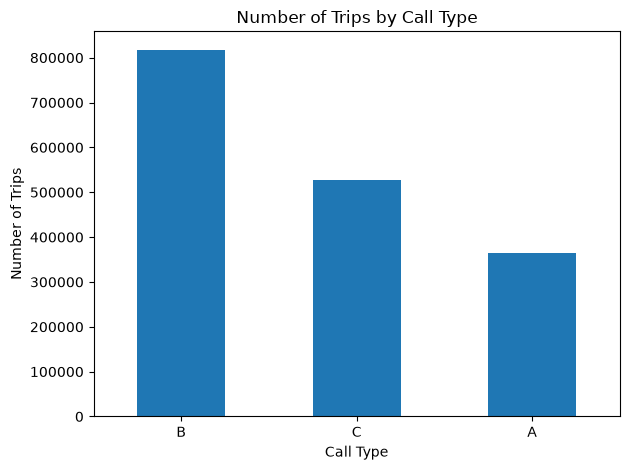

In [2]:
# Load only the column needed for this analysis
call_type = pd.read_csv(
    "data/porto.csv",
    usecols=["CALL_TYPE"]
)

# Number of trips for each call type
call_type_counts = call_type["CALL_TYPE"].value_counts()

print("Number of trips by call type:")
print(call_type_counts)

# Percentage of trips for each call type
call_type_percentages = call_type["CALL_TYPE"].value_counts(normalize=True) * 100

print("\nPercentage of trips by call type:")
print(call_type_percentages)

# Visualisation
call_type_counts.plot(kind="bar")
plt.title("Number of Trips by Call Type")
plt.xlabel("Call Type")
plt.ylabel("Number of Trips")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.2 Distribution of trips per taxi

The number of trips associated with each taxi is examined using `TAXI_ID`. The analysis calculates the mean, median, standard deviation, minimum, maximum, and quartiles, and visualises the distribution.

Distribution of trips per taxi:
count      448.000000
mean      3818.459821
std       1644.021173
min          1.000000
25%       2694.000000
50%       3732.000000
75%       5023.250000
max      10746.000000
dtype: float64


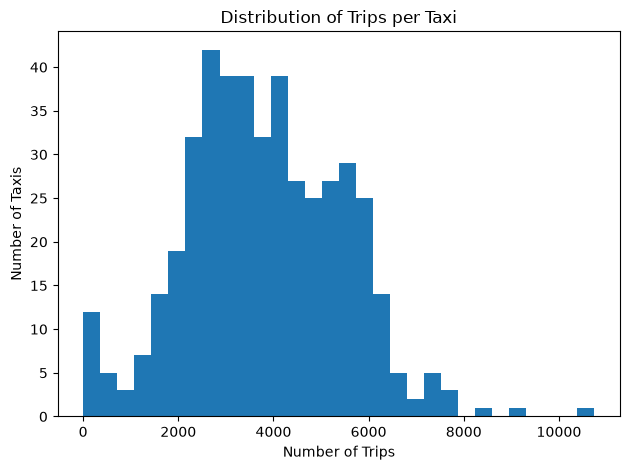

In [3]:
# Count trips for each taxi in chunks to reduce memory usage
trips_per_taxi = pd.Series(dtype="int64")

for chunk in pd.read_csv(
    "data/porto.csv",
    usecols=["TAXI_ID"],
    chunksize=100_000
):
    chunk_counts = chunk["TAXI_ID"].value_counts()
    trips_per_taxi = trips_per_taxi.add(chunk_counts, fill_value=0)

trips_per_taxi = trips_per_taxi.astype(int)

print("Distribution of trips per taxi:")
print(trips_per_taxi.describe())

# Visualisation
plt.hist(trips_per_taxi, bins=30)
plt.title("Distribution of Trips per Taxi")
plt.xlabel("Number of Trips")
plt.ylabel("Number of Taxis")
plt.tight_layout()
plt.show()

### 4.3 Distribution of trajectory length and approximate trip duration

`POLYLINE` contains the GPS trajectory for each trip. GPS points are recorded at 15-second intervals, so the number of GPS points can be used to estimate trip duration.

The trajectory strings are processed in chunks rather than loading the entire `POLYLINE` column into memory at once. Empty trajectories (`[]`) are retained as a separate observation and excluded only from the duration statistics because no duration can be inferred from an empty trajectory.

In [4]:
# Count GPS points for each trajectory in chunks
gps_point_counts = []

for chunk in pd.read_csv(
    "data/porto.csv",
    usecols=["POLYLINE"],
    chunksize=100_000
):
    # GPS points are separated by '],[' in the stored trajectory string.
    points = chunk["POLYLINE"].str.count(r"\]\s*,\s*\[") + 1

    # An empty trajectory contains zero GPS points.
    points[chunk["POLYLINE"] == "[]"] = 0

    gps_point_counts.append(points)

num_gps_points = pd.concat(gps_point_counts, ignore_index=True)

print("Distribution of GPS points per trip:")
print(num_gps_points.describe())

# Number of trips with empty trajectories
empty_trajectories = (num_gps_points == 0).sum()
print(f"\nTrips with empty trajectories: {empty_trajectories}")
print(f"Percentage of trips with empty trajectories: {empty_trajectories / len(num_gps_points) * 100:.3f}%")

Distribution of GPS points per trip:
count    1.710670e+06
mean     4.875831e+01
std      4.565372e+01
min      0.000000e+00
25%      2.800000e+01
50%      4.100000e+01
75%      5.900000e+01
max      3.881000e+03
Name: POLYLINE, dtype: float64

Trips with empty trajectories: 5901
Percentage of trips with empty trajectories: 0.345%


Distribution of approximate trip duration:
count    1.704769e+06
mean     1.198177e+01
std      1.141057e+01
min      0.000000e+00
25%      6.750000e+00
50%      1.000000e+01
75%      1.450000e+01
max      9.700000e+02
Name: POLYLINE, dtype: float64


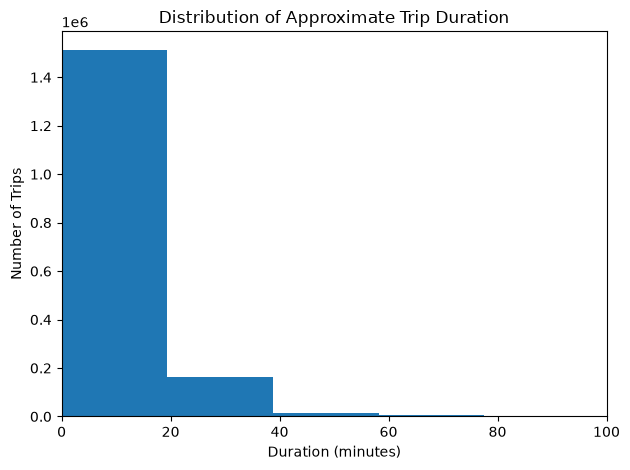

In [5]:
# Estimate trip duration only for trips with at least one GPS point
valid_gps_points = num_gps_points[num_gps_points > 0]
duration_minutes = (valid_gps_points - 1) * 15 / 60

print("Distribution of approximate trip duration:")
print(duration_minutes.describe())

# Visualisation: focus on 0-100 minutes to make the main distribution visible.
# The full statistics above retain all observations, including longer trips.
plt.hist(duration_minutes, bins=50)
plt.title("Distribution of Approximate Trip Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Trips")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()